## **Question 1**

In [38]:
import pandas as pd

sales = [500,600,700,550,620,750]

index = [
    ['North', 'North', 'South', 'North', 'North', 'South'],
    ['West','East','Central','West','East','Central']
]

data = pd.Series(sales, index=index)
print(data)

North  West       500
       East       600
South  Central    700
North  West       550
       East       620
South  Central    750
dtype: int64


In [56]:
data.index.names = ['Region', 'Sub-region']
data.name = 'Sales'
print(data)

Region  Sub-region
North   West          500
        East          600
South   Central       700
North   West          550
        East          620
South   Central       750
Name: Sales, dtype: int64


In [60]:
data.loc['South']

Sub-region
Central    700
Central    750
Name: Sales, dtype: int64

In [62]:
total_sales_region = data.groupby('Region').sum()
total_sales_region

Region
North    2270
South    1450
Name: Sales, dtype: int64

In [64]:
total_sales_subregion = data.groupby('Sub-region').sum()
total_sales_subregion

Sub-region
Central    1450
East       1220
West       1050
Name: Sales, dtype: int64

In [66]:
df = data.reset_index()
df

,Region,Sub-region,Sales
0,North,West,500
1,North,East,600
2,South,Central,700
3,North,West,550
4,North,East,620
5,South,Central,750


In [68]:
data.sort_values(ascending=False)

Region  Sub-region
South   Central       750
        Central       700
North   East          620
        East          600
        West          550
        West          500
Name: Sales, dtype: int64

## **Question 2**

In [15]:
#(a)
import pandas as pd
pop = pd.read_csv("state-population.csv")
areas = pd.read_csv("state-areas.csv")
abbrevs = pd.read_csv("state-abbrevs.csv")

print(pop.head(),'\n')
print(areas.head(),'\n')
print(abbrevs.head())

  state/region     ages  year  population
0           AL  under18  2012   1117489.0
1           AL    total  2012   4817528.0
2           AL  under18  2010   1130966.0
3           AL    total  2010   4785570.0
4           AL  under18  2011   1125763.0 

        state  area (sq. mi)
0     Alabama          52423
1      Alaska         656425
2     Arizona         114006
3    Arkansas          53182
4  California         163707 

        state abbreviation
0     Alabama           AL
1      Alaska           AK
2     Arizona           AZ
3    Arkansas           AR
4  California           CA


In [69]:
#(b)
merged = pd.merge(pop, abbrevs, left_on = 'state/region', right_on = 'abbreviation', how = 'left')

#(c)
merged = merged.drop('abbreviation', axis=1)

print(merged.head())

  state/region     ages  year  population    state
0           AL  under18  2012   1117489.0  Alabama
1           AL    total  2012   4817528.0  Alabama
2           AL  under18  2010   1130966.0  Alabama
3           AL    total  2010   4785570.0  Alabama
4           AL  under18  2011   1125763.0  Alabama


In [73]:
#(d)
missing_value = merged.isnull().sum()
print("Missing values per column:\n", missing_value[missing_value > 0])

merged = merged.dropna()

Missing values per column:
 population    20
state         96
dtype: int64


In [75]:
#(e)
final = pd.merge(merged, areas, on = 'state', how = 'left')

print(final.head())

  state/region     ages  year  population    state  area (sq. mi)
0           AL  under18  2012   1117489.0  Alabama          52423
1           AL    total  2012   4817528.0  Alabama          52423
2           AL  under18  2010   1130966.0  Alabama          52423
3           AL    total  2010   4785570.0  Alabama          52423
4           AL  under18  2011   1125763.0  Alabama          52423


In [81]:
#(f)
final.isnull().sum()
final = final.dropna()

In [109]:
#(g)
Data2010 = final.query("year == 2010 and ages =='total'")

In [111]:
Data2010 = Data2010.set_index('state')

In [113]:
Data2010['density'] = Data2010['population'] / Data2010['area (sq. mi)']

In [115]:
Data2010 = Data2010.sort_values(by= 'density', ascending =False)

In [117]:
print("5 Least Densely Populated States:\n")
print(Data2010.tail(5))

5 Least Densely Populated States:

             state/region   ages  year  population  area (sq. mi)    density
state                                                                       
South Dakota           SD  total  2010    816211.0          77121  10.583512
North Dakota           ND  total  2010    674344.0          70704   9.537565
Montana                MT  total  2010    990527.0         147046   6.736171
Wyoming                WY  total  2010    564222.0          97818   5.768079
Alaska                 AK  total  2010    713868.0         656425   1.087509


## **Question 3**

In [135]:
import pandas as pd

#(a)
performance = pd.read_csv("employee_performance_data.csv", index_col="Employee_ID")
details = pd.read_csv("employee_details.csv")


In [143]:
#(b)
filtered_sales = performance[(performance['Department'] == 'Sales') &
                             (performance['Performance_Score'] > 4 )]
print(filtered_sales)

                    Name Department  Monthly_Salary  Years_at_Company  \
Employee_ID                                                             
112          Employee 12      Sales            6566                 5   
118          Employee 18      Sales            5184                 6   
120          Employee 20      Sales            6462                 1   
125          Employee 25      Sales            3282                15   
128          Employee 28      Sales            5820                14   

             Performance_Score  Last_Promotion_Year Work_Location  
Employee_ID                                                        
112                        5.0                 2021         Rural  
118                        5.0                 2019         Rural  
120                        4.1                 2016         Rural  
125                        4.2                 2023         Urban  
128                        4.9                 2021         Rural  


In [151]:
#(c)
merged = performance.reset_index().merge(details, on = 'Employee_ID')
merged

#or do like this
#merged = performance.merge(details, left_index=True, right_on="Employee_ID")


,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456


In [157]:
#(d)
high_salary_employees = merged[merged['Monthly_Salary'] > 4500]
high_salary_employees

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456


In [163]:
#(e)
email_list = high_salary_employees['Email'].tolist()
print(email_list)

['alice.johnson@example.com', 'cathy.lee@example.com', 'emma.wilson@example.com', 'frank.knight@example.com', 'grace.white@example.com']


In [181]:
#(f)
merged_sorted = merged.sort_values(by = ['Department', 'Performance_Score'] , ascending = [True,False])
merged_sorted

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012


In [183]:
#(g)
merged_reorder = merged_sorted[['Name', 'Department', 'Monthly_Salary', 'Performance_Score', 'Email', 'Phone_Number']]
merged_reorder

,Name,Department,Monthly_Salary,Performance_Score,Email,Phone_Number
6,Employee 7,HR,4625,5.0,grace.white@example.com,7890123456
5,Employee 6,HR,5202,4.6,frank.knight@example.com,6789012345
1,Employee 2,HR,4073,3.1,bob.smith@example.com,2345678901
3,Employee 4,IT,4276,4.3,david.brown@example.com,4567890123
4,Employee 5,IT,7720,4.0,emma.wilson@example.com,5678901234
0,Employee 1,Marketing,6021,4.7,alice.johnson@example.com,1234567890
2,Employee 3,Sales,7613,3.7,cathy.lee@example.com,3456789012


In [185]:
#(h)
merged_sorted['Years_Since_Last_Promotion'] = 2024- merged_sorted['Last_Promotion_Year']
merged_sorted

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number,Years_Since_Last_Promotion
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456,1
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345,1
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901,3
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123,8
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234,6
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890,0
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012,0


In [189]:
#(i)
def get_promotion_status(row):
    if row['Years_Since_Last_Promotion'] <=2 :
        return 'Recently Promoted'
    elif row['Years_Since_Last_Promotion'] > 5 and row['Years_Since_Last_Promotion'] >= 4 :
        return 'Due for Promotion'
    else:
        return 'No Promotion Needed'
    
merged_sorted['Promotion_Status'] = merged_sorted.apply(get_promotion_status, axis = 1)
merged_sorted

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number,Years_Since_Last_Promotion,Promotion_Status
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456,1,Recently Promoted
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345,1,Recently Promoted
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901,3,No Promotion Needed
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123,8,Due for Promotion
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234,6,Due for Promotion
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890,0,Recently Promoted
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012,0,Recently Promoted


## **Question 4**

In [196]:
#(a)
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

products = pd.read_csv("products_sales.csv")

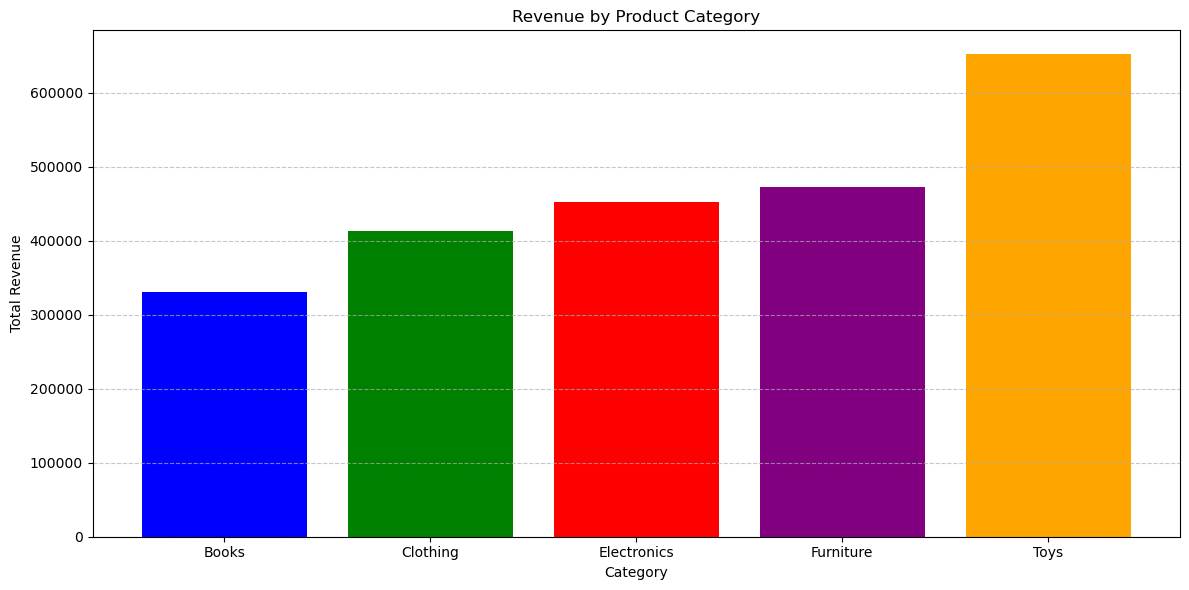

In [202]:
category_revenue = products.groupby('Category')['Revenue'].sum()

# Prepare x and y values
x = category_revenue.index
y = category_revenue.values

# Set up colors
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Create the plot
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(x, y, color=colors)

# Titles and labels
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [208]:
top_category = category_revenue.idxmax()
print("Category with highest revenue:", top_category)


Category with highest revenue: Toys


In [213]:
category_revenue = products.groupby('Category')['Revenue'].sum()
print(category_revenue)

Category
Books          331317
Clothing       413142
Electronics    452286
Furniture      472348
Toys           651777
Name: Revenue, dtype: int64


Yes, there is a significant difference. For example, Books generated around 3000000 while Clothing only brought in around 400,000.

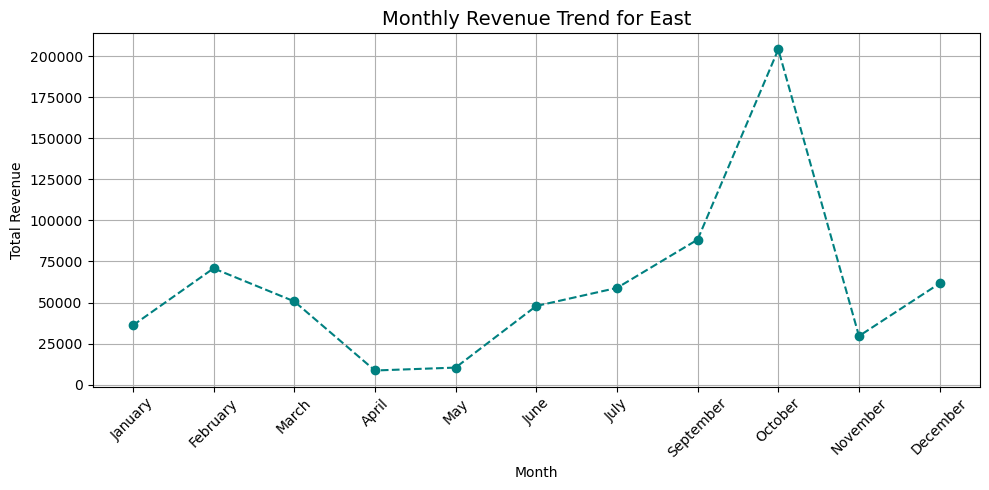

In [216]:
#(d) line plot
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Find top-performing region
top_region = products.groupby('Region')['Revenue'].sum().idxmax()

# Step 2: Filter data for top region
top_region_data = products[products['Region'] == top_region]

# Step 3: Group by month and sum revenue
monthly_revenue = top_region_data.groupby('Month')['Revenue'].sum()

# Optional: Ensure months are ordered correctly
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue = monthly_revenue.reindex(months_order).dropna()

# Step 4: Plot using subplot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly_revenue.index, monthly_revenue.values,
        marker='o', linestyle='--', color='teal')

ax.set_title(f"Monthly Revenue Trend for {top_region}", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [218]:
# Step 1: Map each month to its quarter
month_to_quarter = {
    'January': 'Q1', 'February': 'Q1', 'March': 'Q1',
    'April': 'Q2', 'May': 'Q2', 'June': 'Q2',
    'July': 'Q3', 'August': 'Q3', 'September': 'Q3',
    'October': 'Q4', 'November': 'Q4', 'December': 'Q4'
}

# Step 2: Create a new 'Quarter' column
products['Quarter'] = products['Month'].map(month_to_quarter)

# Step 3: Group by Quarter and sum Revenue
quarterly_revenue = products.groupby('Quarter')['Revenue'].sum()

# Step 4: Find highest and lowest quarters
highest_quarter = quarterly_revenue.idxmax()
lowest_quarter = quarterly_revenue.idxmin()

# Display results
print("Quarterly Revenue:")
print(quarterly_revenue)
print(f"\n✅ Highest Revenue Quarter: {highest_quarter}")
print(f"✅ Lowest Revenue Quarter: {lowest_quarter}")

Quarterly Revenue:
Quarter
Q1    450887
Q2    535660
Q3    531608
Q4    802715
Name: Revenue, dtype: int64

✅ Highest Revenue Quarter: Q4
✅ Lowest Revenue Quarter: Q1
